### Logistic Regression

In [1]:
#importing modules for regression
import statsmodels.api as sm
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn.metrics import precision_recall_curve,auc,f1_score
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve


In [2]:
from sklearn.metrics import balanced_accuracy_score,classification_report
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

In [3]:
#reading the CSV file
logistic_df=pd.read_csv("cardiac.csv")

In [4]:
#dropping the caseno feature from the dataset
logistic_df=logistic_df.drop("caseno",axis=1)

In [5]:
#dummy coding or encoding the categorical data
logistic_df=logistic_df.join(pd.get_dummies(logistic_df.gender,prefix='se',dtype=int).iloc[:,1:]).drop(['gender'],axis=1)
logistic_df=logistic_df.join(pd.get_dummies(logistic_df.cardiac_condition,prefix='se',dtype=int).iloc[:,1:]).drop(['cardiac_condition'],axis=1)

In [6]:
#verifying the dataframe
logistic_df

,age,weight,fitness_score,se_Male,se_Present
0,37,70.47,55.79,1,0
1,73,50.34,35.00,0,0
2,46,87.65,42.93,1,1
3,36,89.80,28.30,0,1
4,34,103.02,40.56,1,0
...,...,...,...,...,...
95,42,111.98,33.73,1,1
96,43,88.07,49.22,1,1
97,45,94.07,41.97,1,1
98,58,97.46,35.20,1,1


In [7]:
#renaming the newly created features after creating dummies
logistic_df.rename(columns= {'se_Male':'gender', 'se_Present':'cardiac_condition'}, inplace = True)

In [8]:
#verify the data types
logistic_df.dtypes

age                    int64
weight               float64
fitness_score        float64
gender                 int32
cardiac_condition      int32
dtype: object

In [9]:
#check for nulls 
logistic_df.isnull().sum()


age                  0
weight               0
fitness_score        0
gender               0
cardiac_condition    0
dtype: int64

In [10]:
#check for na values
logistic_df.isna().sum()

age                  0
weight               0
fitness_score        0
gender               0
cardiac_condition    0
dtype: int64

In [11]:
#splitting the data to train and test dataset
logistic_train, logistic_test= train_test_split(logistic_df,test_size=0.2,random_state=22188801)

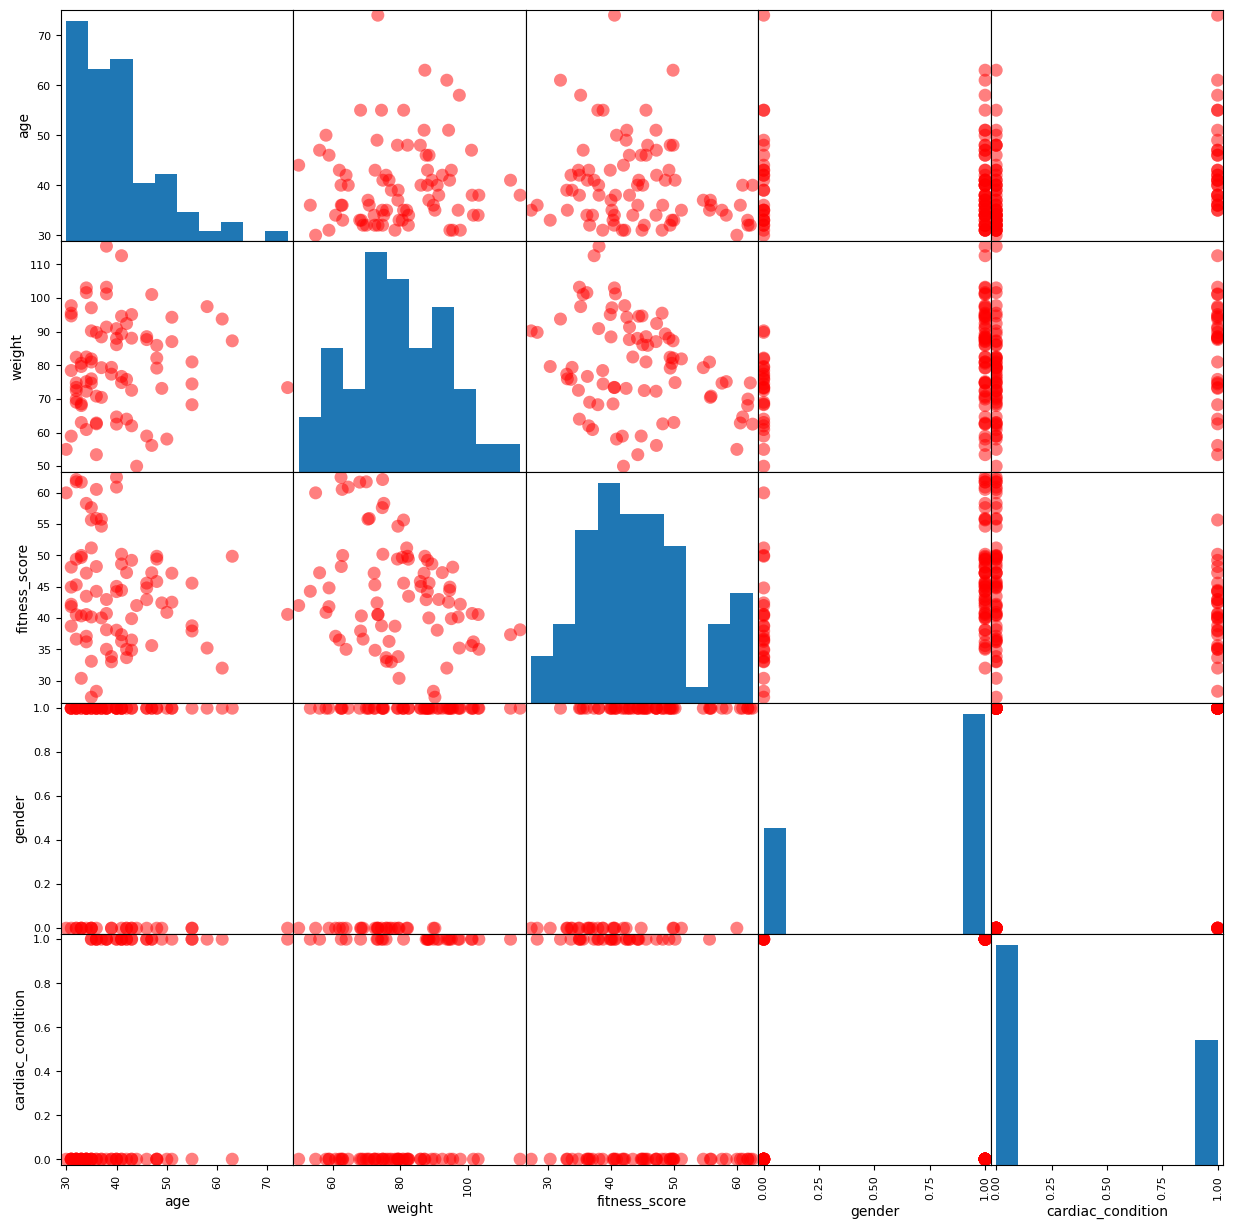

In [12]:
#scatterplot to verify the presence of pattern betweent he variables
pd.plotting.scatter_matrix(logistic_train,color='red', figsize = [15,15], s=350);
plt.show()


In [13]:
#splitting the independent and dependent variables
X_train=logistic_train.drop(['cardiac_condition'],axis=1)
y_train=logistic_train['cardiac_condition']

X_test=logistic_test.drop(['cardiac_condition'],axis=1)
y_test=logistic_test['cardiac_condition']

<Axes: xlabel='age', ylabel='cardiac_condition'>

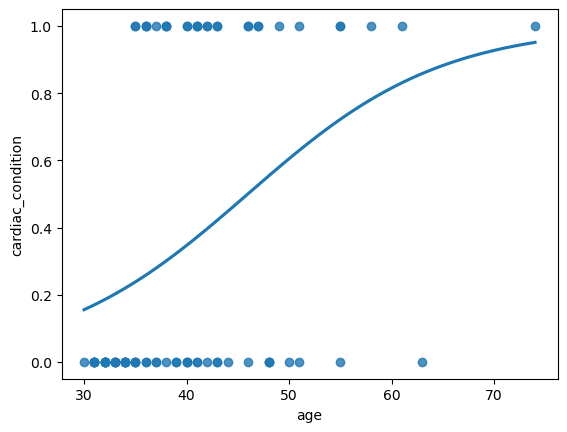

In [14]:
#reglot to verify the distribution of the cardiac condition
sns.regplot(x=X_train['age'],y=y_train,logistic=True, ci=None)

<Axes: xlabel='weight', ylabel='cardiac_condition'>

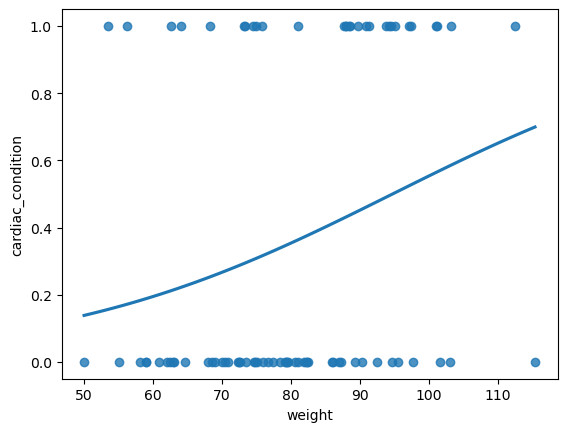

In [15]:
sns.regplot(x=X_train['weight'],y=y_train,logistic=True, ci=None)

<Axes: xlabel='fitness_score', ylabel='cardiac_condition'>

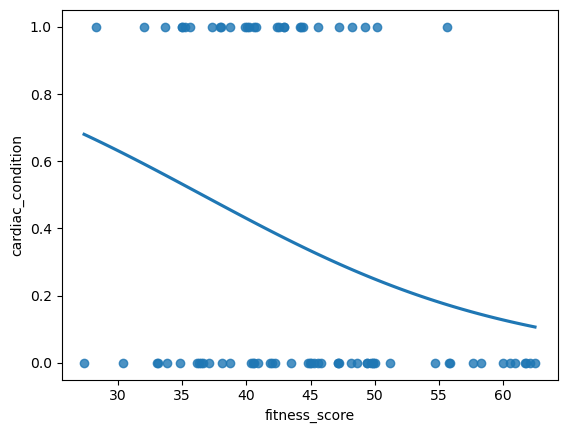

In [16]:
sns.regplot(x=X_train['fitness_score'],y=y_train,logistic=True, ci=None)

<Axes: xlabel='gender', ylabel='cardiac_condition'>

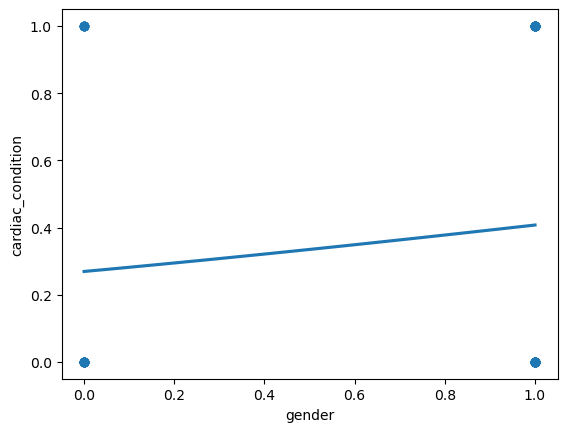

In [17]:
sns.regplot(x=X_train['gender'],y=y_train,logistic=True, ci=None)

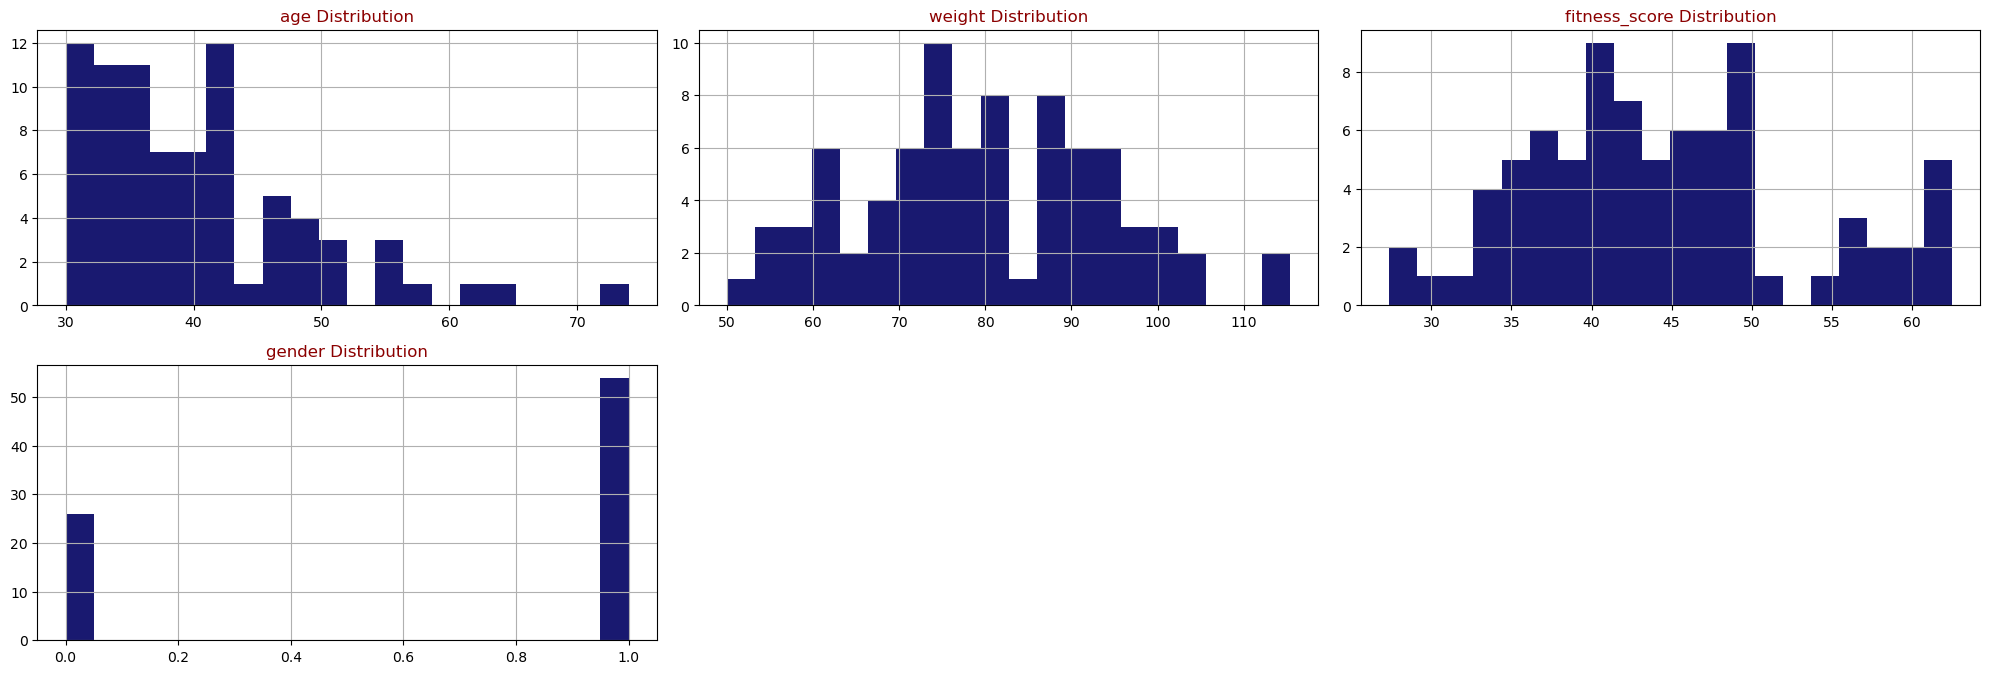

In [18]:
#histogram to find the distribution of the data
def draw_histograms(dataframe, features, rows, cols):
    fig=plt.figure(figsize=(20,20))
    for i, feature in enumerate(features):
        ax=fig.add_subplot(rows,cols,i+1)
        dataframe[feature].hist(bins=20,ax=ax,facecolor='midnightblue')
        ax.set_title(feature+" Distribution",color='DarkRed')
        
    fig.tight_layout()  
    plt.show()
draw_histograms(X_train,X_train.columns,6,3)

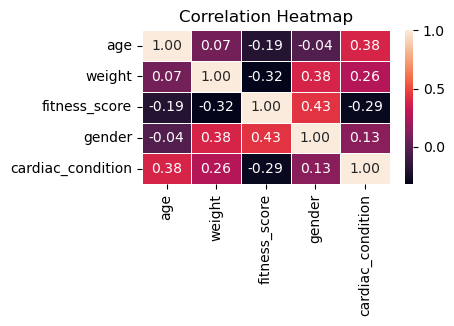

In [19]:
#correlation plot to find the correlation between the variables
plt.figure(figsize=(4,2), dpi =100)

sns.heatmap(logistic_train.corr(method = 'pearson'),annot=True,fmt=".2f", linewidth=.5)
plt.title('Correlation Heatmap')
plt.show()

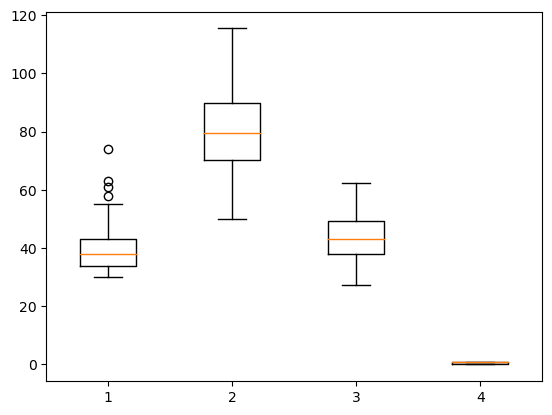

In [20]:
#look for any outliers
t=plt.boxplot(X_train[['age', 'weight', 'fitness_score', 'gender']])


In [21]:
#invoking the logit function to fit the train data
fit=sm.Logit(y_train,sm.add_constant(X_train)).fit()



Optimization terminated successfully.
         Current function value: 0.488834
         Iterations 7


In [22]:
print(fit.summary())

                           Logit Regression Results                           
Dep. Variable:      cardiac_condition   No. Observations:                   80
Model:                          Logit   Df Residuals:                       75
Method:                           MLE   Df Model:                            4
Date:                Wed, 03 Jan 2024   Pseudo R-squ.:                  0.2535
Time:                        22:08:41   Log-Likelihood:                -39.107
converged:                       True   LL-Null:                       -52.387
Covariance Type:            nonrobust   LLR p-value:                 2.438e-05
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             1.1541      3.829      0.301      0.763      -6.350       8.659
age               0.1091      0.038      2.877      0.004       0.035       0.183
weight           -0.0077      0.025     

In [23]:
#dropping the insignificant column in the dataset
X_tra=X_train.drop('weight',axis=1)

In [24]:
#fitting the model again with the reduced columns 
fit2=sm.Logit(y_train,sm.add_constant(X_tra)).fit()


Optimization terminated successfully.
         Current function value: 0.489411
         Iterations 7


In [25]:
print(fit2.summary())

                           Logit Regression Results                           
Dep. Variable:      cardiac_condition   No. Observations:                   80
Model:                          Logit   Df Residuals:                       76
Method:                           MLE   Df Model:                            3
Date:                Wed, 03 Jan 2024   Pseudo R-squ.:                  0.2526
Time:                        22:08:41   Log-Likelihood:                -39.153
converged:                       True   LL-Null:                       -52.387
Covariance Type:            nonrobust   LLR p-value:                 7.606e-06
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.2252      2.300      0.098      0.922      -4.284       4.734
age               0.1087      0.038      2.873      0.004       0.035       0.183
fitness_score    -0.1552      0.053     

In [26]:
#calculating the logodds of the coeffiecients for the logistic regression
np.exp(fit2.params)

const            1.252559
age              1.114811
fitness_score    0.856223
gender           8.324949
dtype: float64

In [27]:
# Wald test to find the significance of the variables in the logistic model
fit.wald_test("(age=0,fitness_score=0,gender=0)")

C:\Users\jackb\anaconda3\Lib\site-packages\statsmodels\base\model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


<class 'statsmodels.stats.contrast.ContrastResults'>
<Wald test (chi2): statistic=[[12.73437217]], p-value=0.0052477150230720825, df_denom=3>

In [28]:
#preparing the test dataset
X_test=X_test.drop('weight',axis=1)

In [29]:
#predict function invoked to evaluate the data
predicted_probabilities=fit2.predict(sm.add_constant(X_test))

In [30]:
#cleaning the data for the bivariate results
predicted=[1 if x>0.5 else 0 for x in predicted_probabilities]

In [31]:
#classification report
print(classification_report(y_test,predicted))

              precision    recall  f1-score   support

           0       0.85      0.79      0.81        14
           1       0.57      0.67      0.62         6

    accuracy                           0.75        20
   macro avg       0.71      0.73      0.72        20
weighted avg       0.76      0.75      0.75        20



In [32]:
#F1 score
f1_score(y_test,predicted)


0.6153846153846153

In [33]:
#balanced accuracy score
balanced_accuracy_score(y_test,predicted)

0.7261904761904762

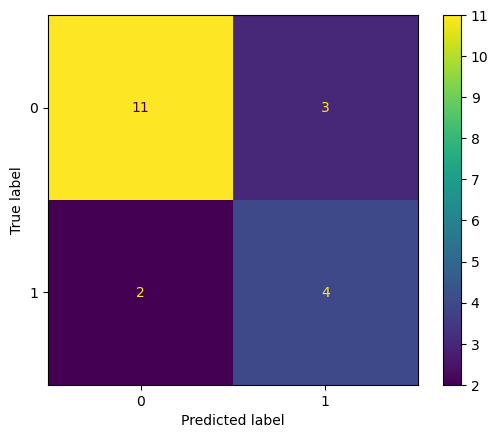

In [34]:
#plotting the confusion matrix
_=ConfusionMatrixDisplay(confusion_matrix(y_test,predicted)).plot()

Text(0, 0.5, 'True Positive Rate')

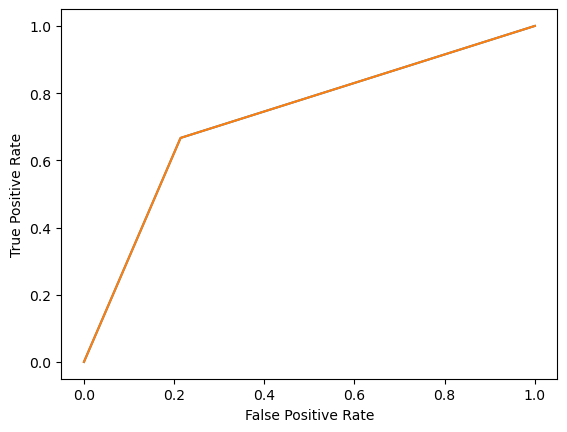

In [35]:
fpr, tpr, thresholds = roc_curve(y_test, predicted)
auc = metrics.roc_auc_score(y_test, predicted)
plt.plot(fpr,tpr,label="AUC="+str(auc))

plt.plot(fpr, tpr)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

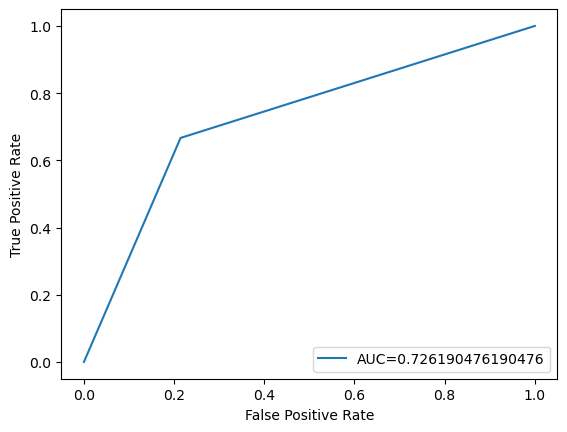

In [36]:
#plotting the AUC curve

# fpr=
auc = metrics.roc_auc_score(y_test, predicted)
plt.plot(fpr,tpr,label="AUC="+str(auc))
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

plt.legend(loc=4)
plt.show()

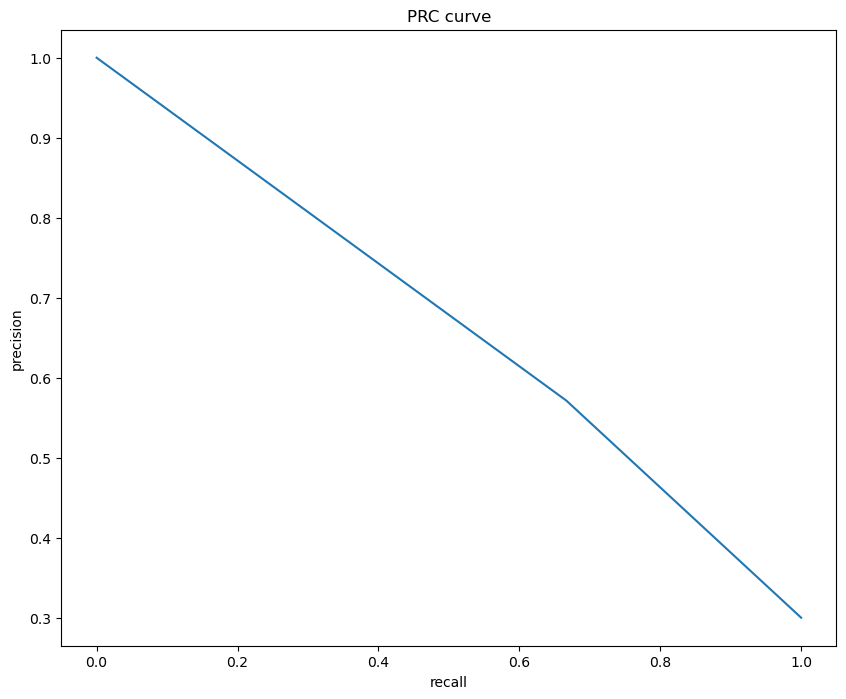

In [37]:
#plotting the precision recall curve
precision, recall, thresholds = precision_recall_curve(y_test, predicted)
plt.figure(figsize = (10,8))
# plt.plot([0, 1], [0.5, 0.5],'k--')
plt.plot(recall, precision, label = 'Logistic')
plt.xlabel('recall')
plt.ylabel('precision')
plt.title('PRC curve')
plt.show()
